In [1]:
from pyspark.sql import SparkSession, DataFrame, functions as F
import configparser
from pathlib import Path
from pyspark.ml.feature import VectorAssembler
import xgboost
from xgboost.spark import SparkXGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
import pyspark.sql.window as window




In [2]:
def _load_config(config_path: str = "config/config.conf") -> configparser.ConfigParser:
    config = configparser.ConfigParser()
    # Lấy thư mục cha của thư mục hiện tại (ml_lab -> FInal_Projects)
    project_root = Path().resolve().parent 
    loaded = config.read(project_root / config_path)
    if not loaded:
        raise FileNotFoundError(f"Could not read config file at {project_root / config_path}")
    return config



def _build_spark_session_for_ml(config: configparser.ConfigParser) -> SparkSession:
    # Lấy key từ config
    minio_access_key = config.get("minio", "access_key")
    minio_secret_key = config.get("minio", "secret_key")
    
    # KHI CHẠY LOCAL: Dùng localhost và cổng 9010 (cổng đã map trong docker-compose)
    local_endpoint = "http://localhost:9010"

    return (
        SparkSession.builder.appName("baseline_ml_lab")
        # Sử dụng Version phù hợp với Spark 4.1 local của bạn
        .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.4.1,software.amazon.awssdk:bundle:2.28.15")
        
        .config("spark.hadoop.fs.s3a.endpoint", local_endpoint)
        .config("spark.hadoop.fs.s3a.access.key", minio_access_key)
        .config("spark.hadoop.fs.s3a.secret.key", minio_secret_key)
        .config("spark.hadoop.fs.s3a.path.style.access", "true")
        .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
        .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")
        .getOrCreate()
    )




In [3]:
def _read_ml_path(config: configparser.ConfigParser) -> str:
    return f"s3a://gold/ml/training/daily_demand_features/"


In [5]:
config = _load_config()
spark = _build_spark_session_for_ml(config)
input_path = _read_ml_path(config)
silver_df: DataFrame = spark.read.option("mergeSchema", "true").parquet(input_path)

In [20]:
silver_df.printSchema()

root
 |-- trip_date: date (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- target_demand: long (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- lag_28d: long (nullable = true)
 |-- lag_35d: long (nullable = true)
 |-- rolling_28d_avg: double (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- feature_year: integer (nullable = true)
 |-- feature_month: integer (nullable = true)
 |-- rolling_median: double (nullable = true)
 |-- zone_type: integer (nullable = false)



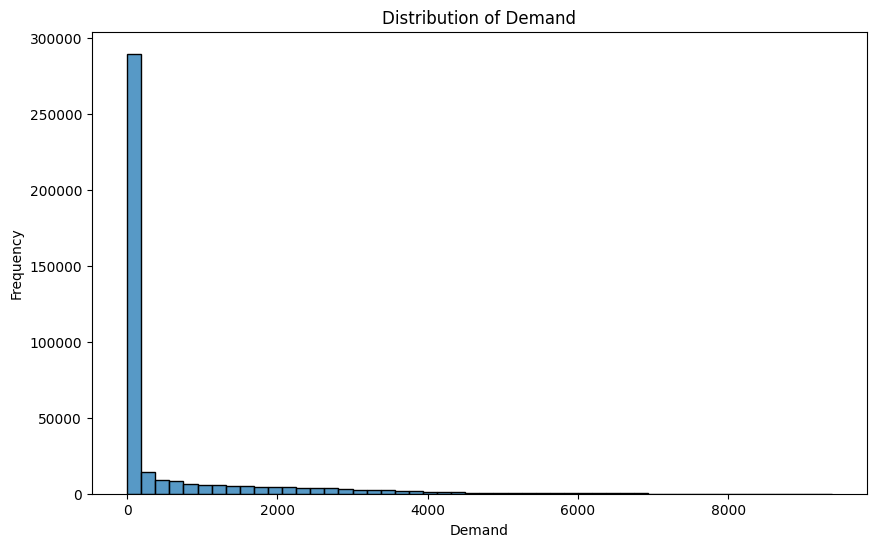

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(silver_df.select("target_demand").rdd.flatMap(lambda x: x).collect(), bins=50)
plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()

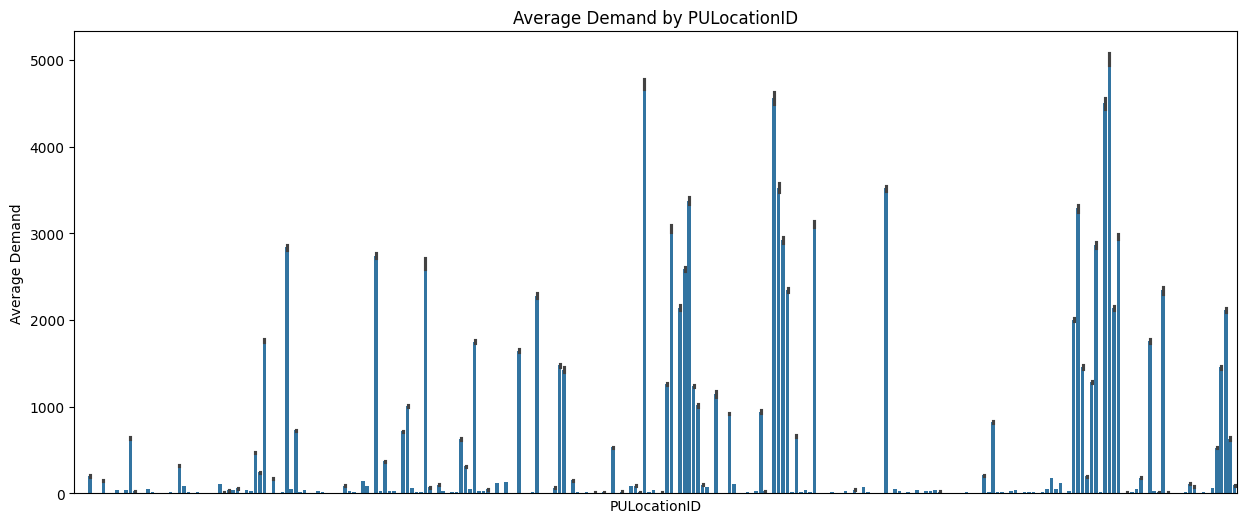

In [27]:
plt.figure(figsize=(15, 6))
sns.barplot(x="PULocationID", y="target_demand", data=silver_df.toPandas())
plt.title("Average Demand by PULocationID")
plt.xlabel("PULocationID")
plt.ylabel("Average Demand")
plt.xticks([])
plt.show()

In [6]:
# Compute zone_type
from pyspark.sql import Window


window_zone = Window.partitionBy('PULocationID').orderBy('trip_date').rowsBetween(-89, 0)
silver_df = silver_df.withColumn('rolling_median', F.avg('rolling_28d_avg').over(window_zone))
threshold = silver_df.approxQuantile('rolling_median', [0.75], 0.01)[0]
silver_df = silver_df.withColumn('zone_type', F.when(F.col('rolling_median') > threshold, 1).otherwise(0))
print(f'Threshold high/low: {threshold}')
silver_df.groupBy('zone_type').count().show()


Threshold high/low: 244.24563492063487


+---------+------+
|zone_type| count|
+---------+------+
|        1|100663|
|        0|296720|
+---------+------+



In [7]:
silver_df.filter(F.col("feature_year") == 2026).filter(F.col("feature_month") == 3).select("PULocationID", "trip_date", "target_demand", "rolling_28d_avg", "rolling_median", "zone_type").show(20, truncate=False)

+------------+----------+-------------+------------------+------------------+---------+
|PULocationID|trip_date |target_demand|rolling_28d_avg   |rolling_median    |zone_type|
+------------+----------+-------------+------------------+------------------+---------+
|181         |2026-03-01|1            |156.5             |156.69325396825397|0        |
|234         |2026-03-01|1            |3032.5            |3156.2166666666662|1        |
|74          |2026-03-01|2            |849.25            |884.9599206349208 |1        |
|141         |2026-03-01|1            |2595.285714285714 |2759.519444444443 |1        |
|163         |2026-03-01|1            |2701.8214285714284|2969.9591269841267|1        |
+------------+----------+-------------+------------------+------------------+---------+



In [8]:
silver_df.columns

['trip_date',
 'PULocationID',
 'target_demand',
 'day_of_week',
 'is_weekend',
 'month',
 'lag_28d',
 'lag_35d',
 'rolling_28d_avg',
 'is_holiday',
 'feature_year',
 'feature_month',
 'rolling_median',
 'zone_type']

In [9]:
FEATURES = [
 'PULocationID',
 'day_of_week',
 'is_weekend',
 'month',
 'lag_28d',
 'lag_35d',
 'rolling_28d_avg',
 'is_holiday',
 'feature_year',]

TARGET = 'target_demand'

In [10]:
cutoff_train = "2025-07-01"
cutoff_val = "2025-11-01"
cutoff_test = "2026-03-01"

high_df = silver_df.filter(F.col('zone_type') == 1)
low_df = silver_df.filter(F.col('zone_type') == 0)

# Log1p target for train/val
high_train = high_df.filter(F.col("trip_date") < cutoff_train).withColumn("target_demand", F.log1p(F.col("target_demand"))).toPandas()
high_val = high_df.filter((F.col("trip_date") >= cutoff_train) & (F.col("trip_date") < cutoff_val)).withColumn("target_demand", F.log1p(F.col("target_demand"))).toPandas()
low_train = low_df.filter(F.col("trip_date") < cutoff_train).withColumn("target_demand", F.log1p(F.col("target_demand"))).toPandas()
low_val = low_df.filter((F.col("trip_date") >= cutoff_train) & (F.col("trip_date") < cutoff_val)).withColumn("target_demand", F.log1p(F.col("target_demand"))).toPandas()
df_test = silver_df.filter(F.col("trip_date") >= cutoff_val).toPandas()


X_train_high, y_train_high = high_train[FEATURES], high_train[TARGET]
X_val_high, y_val_high = high_val[FEATURES], high_val[TARGET]
X_train_low, y_train_low = low_train[FEATURES], low_train[TARGET]
X_val_low, y_val_low = low_val[FEATURES], low_val[TARGET]
X_test, y_test = df_test[FEATURES], df_test[TARGET]


In [11]:
model_high = xgb.XGBRegressor(
    n_estimators=1500,           # Số cây tối đa (early stopping sẽ dừng sớm hơn)
    learning_rate=0.03,          # Nhỏ hơn baseline → học chắc hơn
    max_depth=8,                 # Đủ để bắt pattern phức tạp
    subsample=0.8,               # Regularization: dùng 80% dòng mỗi cây
    colsample_bytree=0.8,        # Regularization: dùng 80% features mỗi cây
    min_child_weight=5,          # Tránh overfit ở nhánh nhỏ (ít data)
    reg_alpha=0.1,               # L1 regularization
    reg_lambda=1.0,              # L2 regularization
    objective="reg:tweedie",
    random_state=42,
    n_jobs=-1,
)
model_high.fit(X_train_high, y_train_high, eval_set=[(X_train_high, y_train_high), (X_val_high, y_val_high)], early_stopping_rounds=50)

model_low = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:tweedie",
    random_state=42,
    n_jobs=-1,
)
model_low.fit(X_train_low, y_train_low, eval_set=[(X_train_low, y_train_low), (X_val_low, y_val_low)], early_stopping_rounds=50)

[0]	validation_0-tweedie-nloglik@1.5:11.05861	validation_1-tweedie-nloglik@1.5:10.87690
[1]	validation_0-tweedie-nloglik@1.5:11.04155	validation_1-tweedie-nloglik@1.5:10.86132
[2]	validation_0-tweedie-nloglik@1.5:11.02547	validation_1-tweedie-nloglik@1.5:10.84664
[3]	validation_0-tweedie-nloglik@1.5:11.01032	validation_1-tweedie-nloglik@1.5:10.83279


/home/njagz/Documents/FInal_Projects/venv/lib/python3.12/site-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[4]	validation_0-tweedie-nloglik@1.5:10.99604	validation_1-tweedie-nloglik@1.5:10.81974
[5]	validation_0-tweedie-nloglik@1.5:10.98258	validation_1-tweedie-nloglik@1.5:10.80745
[6]	validation_0-tweedie-nloglik@1.5:10.96990	validation_1-tweedie-nloglik@1.5:10.79585
[7]	validation_0-tweedie-nloglik@1.5:10.95794	validation_1-tweedie-nloglik@1.5:10.78493
[8]	validation_0-tweedie-nloglik@1.5:10.94668	validation_1-tweedie-nloglik@1.5:10.77462
[9]	validation_0-tweedie-nloglik@1.5:10.93607	validation_1-tweedie-nloglik@1.5:10.76492
[10]	validation_0-tweedie-nloglik@1.5:10.92608	validation_1-tweedie-nloglik@1.5:10.75581
[11]	validation_0-tweedie-nloglik@1.5:10.91667	validation_1-tweedie-nloglik@1.5:10.74721
[12]	validation_0-tweedie-nloglik@1.5:10.90781	validation_1-tweedie-nloglik@1.5:10.73915
[13]	validation_0-tweedie-nloglik@1.5:10.89946	validation_1-tweedie-nloglik@1.5:10.73153
[14]	validation_0-tweedie-nloglik@1.5:10.89159	validation_1-tweedie-nloglik@1.5:10.72435
[15]	validation_0-tweedie-n

/home/njagz/Documents/FInal_Projects/venv/lib/python3.12/site-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[8]	validation_0-tweedie-nloglik@1.5:6.49777	validation_1-tweedie-nloglik@1.5:7.36649
[9]	validation_0-tweedie-nloglik@1.5:6.49221	validation_1-tweedie-nloglik@1.5:7.35989
[10]	validation_0-tweedie-nloglik@1.5:6.48698	validation_1-tweedie-nloglik@1.5:7.35368
[11]	validation_0-tweedie-nloglik@1.5:6.48205	validation_1-tweedie-nloglik@1.5:7.34792
[12]	validation_0-tweedie-nloglik@1.5:6.47775	validation_1-tweedie-nloglik@1.5:7.34277
[13]	validation_0-tweedie-nloglik@1.5:6.47335	validation_1-tweedie-nloglik@1.5:7.33757
[14]	validation_0-tweedie-nloglik@1.5:6.46919	validation_1-tweedie-nloglik@1.5:7.33270
[15]	validation_0-tweedie-nloglik@1.5:6.46526	validation_1-tweedie-nloglik@1.5:7.32810
[16]	validation_0-tweedie-nloglik@1.5:6.46156	validation_1-tweedie-nloglik@1.5:7.32378
[17]	validation_0-tweedie-nloglik@1.5:6.45833	validation_1-tweedie-nloglik@1.5:7.31997
[18]	validation_0-tweedie-nloglik@1.5:6.45503	validation_1-tweedie-nloglik@1.5:7.31613
[19]	validation_0-tweedie-nloglik@1.5:6.45192

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=-1,
             num_parallel_tree=None, objective='reg:tweedie', ...)

In [12]:
test_df = df_test.copy()
test_df['pred_high'] = model_high.predict(X_test)
test_df['pred_low'] = model_low.predict(X_test)
test_df['prediction'] = np.where(test_df['zone_type'] == 1, np.expm1(test_df['pred_high']), np.expm1(test_df['pred_low']))

# Metrics per group
high_test = test_df[test_df['zone_type'] == 1]
low_test = test_df[test_df['zone_type'] == 0]
print('High RMSE:', np.sqrt(mean_squared_error(high_test['target_demand'], high_test['prediction'])))
print('Low RMSE:', np.sqrt(mean_squared_error(low_test['target_demand'], low_test['prediction'])))
print('Combined RMSE:', np.sqrt(mean_squared_error(test_df['target_demand'], test_df['prediction'])))

High RMSE: 451.79566921402096
Low RMSE: 25.247762868780242
Combined RMSE: 235.44573075704238


In [13]:
test_df.loc[test_df['zone_type'] == 0, ['target_demand', 'prediction']].head(10)

,target_demand,prediction
120,11,12.582562
121,7,13.597852
122,13,11.600368
123,10,12.572185
124,8,11.778119
125,16,11.845341
126,18,11.924770
127,9,13.092978
128,10,13.317807
129,10,12.015598


In [14]:
test_df.loc[test_df['zone_type'] == 1, ['target_demand', 'prediction']].head(10)

,target_demand,prediction
0,522,282.212860
1,391,256.669617
2,193,201.865631
3,196,219.628983
4,177,232.072647
5,202,241.725800
6,230,234.374039
7,317,269.955078
8,366,264.893433
9,168,202.398956
